# Exploratory Analysis: Real vs. Synthetic Clinician Comments

This notebook presents a first look at the phase 2 generation run, bringing the total data generated
up to 6,600 r/AskDocs threads,  with synthetic clinician comments produced by three models (Gemini 2.5 Pro, GPT-5, Grok 4.6) under
three prompting strategies (DG, SAG, SAGII).

The goal of the notebook is to see if the initial observations at 3,000 comments hold up when we double (and then some)
the number of OPs.

**Input:** The required input here is `analysis_dataset_6600.jsonl`, built by `build_analysis_dataset.py`. 
It has one record per thread containing the OP, its real comments, and all nine synthetic sets. It
is a big file, so it is stored in a Google Drive folder (you should have access). The Python script
used to build it can be found in our repository on GitHub.

## 1. Setup

In [1]:
import json
import statistics as st
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

# Point this at analysis_dataset.jsonl (or the .gz, which also works if you
# swap `open` for `gzip.open` below).
DATA_PATH = Path("../output/corpora/analysis_dataset_6600.jsonl")

MODELS = ["gemini", "openai", "grok"]
STRATEGIES = ["dg", "sag", "sagii"]

records = [json.loads(line) for line in open(DATA_PATH)]
print(f"Loaded {len(records):,} threads from {DATA_PATH.name}")

Loaded 6,600 threads from analysis_dataset_6600.jsonl


## 2. Coverage and completeness

Every thread should have real comments and nine synthetic sets. The synthetic count per
thread is designed to match the real comment count, so any mismatch is a defect.

In [2]:
n_real = sum(len(r["real_comments"]) for r in records)
print(f"Threads:             {len(records):,}")
print(f"Real comments:       {n_real:,}")
print()

print(f"{'model/strategy':18} {'comments':>10} {'missing sets':>13} {'empty bodies':>13}")
print("-" * 58)
for m in MODELS:
    for s in STRATEGIES:
        total = missing = empty = 0
        for r in records:
            cl = r["synthetic"][m][s]
            if not cl:
                missing += 1
            total += len(cl)
            empty += sum(1 for c in cl if not c["body"].strip())
        print(f"{m + '/' + s:18} {total:>10,} {missing:>13} {empty:>13}")

Threads:             6,600
Real comments:       8,625

model/strategy       comments  missing sets  empty bodies
----------------------------------------------------------
gemini/dg              14,301             1             0
gemini/sag             14,288             1             0
gemini/sagii           14,301             1             1
openai/dg              14,302             0             0
openai/sag             14,302             0             0
openai/sagii           14,302             0             0
grok/dg                14,258             9             0
grok/sag               14,301             1             1
grok/sagii             14,301             1             1


## 3. Build the comparison groups

Build the data structure for our ten groups: the real comments, plus one for each model * prompting strategy combination.

In [3]:
groups: dict[str, list[str]] = defaultdict(list)

for r in records:
    for c in r["real_comments"]:
        if c["body"].strip():
            groups["real"].append(c["body"])
    for m in MODELS:
        for s in STRATEGIES:
            for c in r["synthetic"][m][s]:
                if c["body"].strip():
                    groups[f"{m}/{s}"].append(c["body"])

ORDER = ["real"] + [f"{m}/{s}" for m in MODELS for s in STRATEGIES]
for k in ORDER:
    print(f"{k:18} {len(groups[k]):>7,} comments")

real                 8,625 comments
gemini/dg           14,301 comments
gemini/sag          14,288 comments
gemini/sagii        14,300 comments
openai/dg           14,302 comments
openai/sag          14,302 comments
openai/sagii        14,302 comments
grok/dg             14,258 comments
grok/sag            14,300 comments
grok/sagii          14,300 comments


## 4. Comment length

The pilot noted that synthetic comments cluster tightly around a target length while real
comments vary a lot. Worth checking whether that holds across all three models.

Because the real distribution is heavily right-skewed (a few very long replies drag the
mean well above the median), the **median** is the fairer comparison.

In [4]:
lengths = {k: [len(t.split()) for t in groups[k]] for k in ORDER}

print(f"{'group':18} {'n':>7} {'mean':>7} {'median':>7} {'SD':>7} {'p90':>6}")
print("-" * 56)
for k in ORDER:
    L = lengths[k]
    p90 = sorted(L)[int(len(L) * 0.90)]
    print(f"{k:18} {len(L):>7,} {st.mean(L):>7.1f} {st.median(L):>7.0f} {st.pstdev(L):>7.1f} {p90:>6}")

group                    n    mean  median      SD    p90
--------------------------------------------------------
real                 8,625    54.0      34    64.5    124
gemini/dg           14,301    32.2      32     9.6     45
gemini/sag          14,288    34.5      34     7.8     45
gemini/sagii        14,300    37.6      37     8.5     48
openai/dg           14,302    60.8      58    27.7    100
openai/sag          14,302    86.0      85    16.4    108
openai/sagii        14,302    86.7      86    15.8    108
grok/dg             14,258    27.9      27    11.2     43
grok/sag            14,300    34.2      33    10.4     48
grok/sagii          14,300    32.3      31     9.2     44


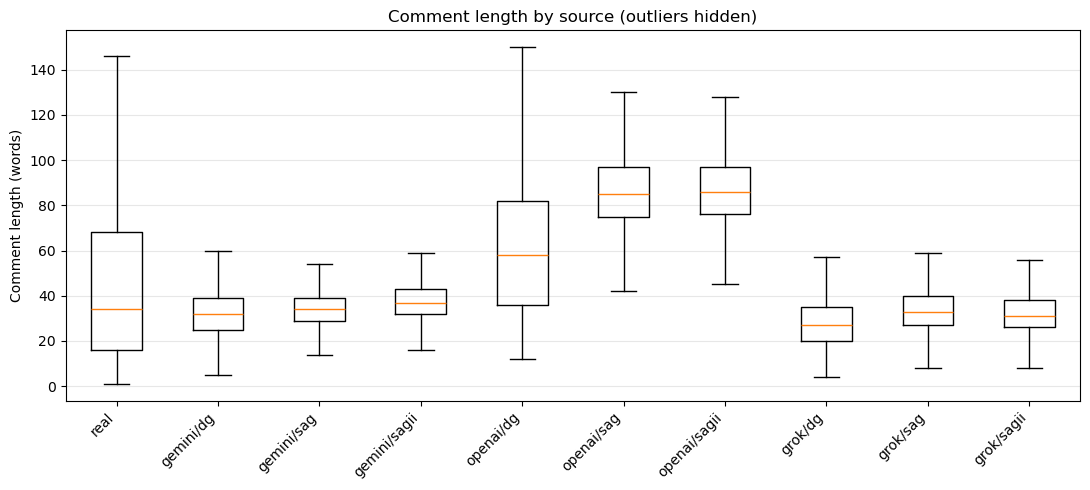

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([lengths[k] for k in ORDER], showfliers=False)
ax.set_xticks(range(1, len(ORDER) + 1))
ax.set_xticklabels(ORDER, rotation=45, ha="right")
ax.set_ylabel("Comment length (words)")
ax.set_title("Comment length by source (outliers hidden)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Question rate: a proxy for EPITOME Explorations

EPITOME's *Explorations* mechanism captures a responder probing for feelings or
circumstances the poster has not stated, which in a medical forum usually surfaces as a
follow-up question ("does it hurt when you press on it?", "any fever?", "which country are
you in?").

Whether a comment contains a question mark is a crude but zero-cost proxy. If the pilot's
Explorations gap is real, real comments should ask questions far more often than synthetic
ones.

In [6]:
def question_rate(texts: list[str]) -> float:
    """Share of comments containing at least one question mark."""
    return 100 * sum("?" in t for t in texts) / len(texts)


qrates = {k: question_rate(groups[k]) for k in ORDER}

print(f"{'group':18} {'% with a question':>18} {'vs real':>10}")
print("-" * 48)
base = qrates["real"]
for k in ORDER:
    ratio = "" if k == "real" else f"{base / qrates[k]:.1f}x lower"
    print(f"{k:18} {qrates[k]:>17.1f}% {ratio:>10}")

group               % with a question    vs real
------------------------------------------------
real                            23.0%           
gemini/dg                        6.8% 3.4x lower
gemini/sag                       6.1% 3.7x lower
gemini/sagii                     5.3% 4.4x lower
openai/dg                        1.5% 15.6x lower
openai/sag                       0.7% 31.6x lower
openai/sagii                     1.3% 17.7x lower
grok/dg                          1.7% 13.3x lower
grok/sag                         2.6% 8.9x lower
grok/sagii                       1.7% 13.9x lower


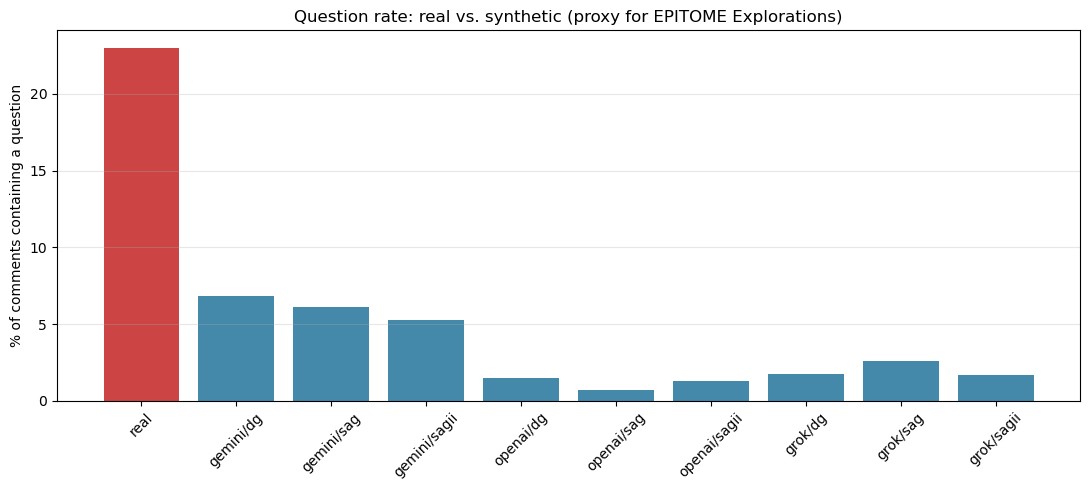

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#c44"] + ["#48a"] * 9
ax.bar(ORDER, [qrates[k] for k in ORDER], color=colors)
ax.set_ylabel("% of comments containing a question")
ax.set_title("Question rate: real vs. synthetic (proxy for EPITOME Explorations)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Is this just a length effect?

Obviously longer comments have more room for a question. If synthetic comments were uniformly
shorter, that alone might explain the gap. Comparing question rates within similar length 
bands separates the two.

In [8]:
BANDS = [(0, 25), (25, 50), (50, 100), (100, 10_000)]

print(f"{'group':18}" + "".join(f"{f'{lo}-{hi}w':>12}" for lo, hi in BANDS))
print("-" * 66)
for k in ORDER:
    cells = []
    for lo, hi in BANDS:
        sub = [t for t in groups[k] if lo <= len(t.split()) < hi]
        cells.append(f"{question_rate(sub):>10.1f}%" if len(sub) >= 30 else f"{'-':>11}")
    print(f"{k:18}" + "".join(cells))
print("\n('-' = fewer than 30 comments in that band, too few to report)")

group                    0-25w      25-50w     50-100w  100-10000w
------------------------------------------------------------------
real                    18.7%      19.8%      26.8%      34.9%
gemini/dg               12.1%       5.5%       1.5%          -
gemini/sag              12.0%       5.7%       1.1%          -
gemini/sagii            15.8%       4.9%       2.1%          -
openai/dg                2.0%       1.6%       1.4%       1.0%
openai/sag                  -       1.1%       0.7%       1.0%
openai/sagii                -       0.0%       1.3%       1.4%
grok/dg                  2.7%       1.0%       0.3%          -
grok/sag                 5.7%       2.0%       1.0%          -
grok/sagii               3.0%       1.4%       0.5%          -

('-' = fewer than 30 comments in that band, too few to report)


## 6. Side-by-side examples

What does this look like in the real vs. synthetic data? These are threads where the real clinician asked a question and
the models did not, which is the pattern the aggregate statistics point to.

In [9]:
def show(rec, width=100):
    print("=" * width)
    print(f"OP: {rec['title'][:width - 4]}")
    body = " ".join(rec["selftext"].split())
    print(f"    {body[:300]}{'...' if len(body) > 300 else ''}\n")
    print("-- REAL --")
    for c in rec["real_comments"]:
        flair = c["author_flair_text"] or "no flair"
        print(f"  [{flair}] {' '.join(c['body'].split())[:300]}")
    for m in MODELS:
        for s in STRATEGIES:
            cl = rec["synthetic"][m][s]
            if not cl:
                continue
            print(f"-- {m.upper()} / {s.upper()} --")
            for c in cl:
                print(f"  {' '.join(c['body'].split())[:300]}")
    print()


# Threads where the real reply asked something but no synthetic reply did
candidates = [
    r
    for r in records
    if r["real_comments"]
    and any("?" in c["body"] for c in r["real_comments"])
    and not any(
        "?" in c["body"]
        for m in MODELS
        for s in STRATEGIES
        for c in r["synthetic"][m][s]
    )
    and len(r["real_comments"]) == 1
]
print(f"{len(candidates):,} threads match this pattern ({100*len(candidates)/len(records):.0f}% of all threads)\n")

for rec in candidates[:3]:
    show(rec)

836 threads match this pattern (13% of all threads)

OP: Numbness after surgery (2022 Aug)
    19f had knee surgery back in August of 22, long story short I’ve had an area of general skin numbness which was checked by my surgeon post op and he said it was nothing of concern. Suddenly, I am experiencing tenderness in the area, not the knee but the skin, so much so that I thought I had bruised ...

-- REAL --
  [Physician] What surgery? Where is the numbness? Nerves generally "heal" at a rate of 1 mm per day but this is far out enough where it's probably not going to change much
-- GEMINI / DG --
  Nerve regeneration can definitely cause some strange sensations as they 'wake up'. Tenderness, tingling, or a pins-and-needles feeling are all pretty common during this process.
-- GEMINI / SAG --
  Tenderness and altered sensation in an area that was previously numb is often a sign that the small cutaneous nerves are starting to recover.
-- GEMINI / SAGII --
  Yes, it's very possible this is 

## 7. Summary of findings

**The data is sound:** From 6,600 threads with 8,625 real comments, we generated 128,653
synthetic comments across nine model/strategy combinations. Of 59,400 possible
thread-generations, 14 produced no output and 3 contained an empty comment, a failure
rate of 0.03%.

**Real clinicians ask questions; models explain:** 23.0% of real comments contain a
question, against 0.7% to 6.8% for every model and every strategy, a gap of 3.4x-31.6x.
This replicates the pilot's Explorations finding at roughly 165x the sample size.

**The result is stable as the sample grows:** At 3,000 threads the figures were 23.3%
real against 0.8% to 7.4% synthetic; at 6,600 they are 23.0% against 0.7% to 6.8%. Every
group moved by less than a percentage point when the sample doubled, which is what a real
effect looks like under replication.

**This is not an artifact of comment length:** Within matched length bands, this gap
*widens*. Real comments ask *more* questions as they get longer (18.7% at under 25 words,
rising to 34.9% above 100), while synthetic comments ask *fewer* (Gemini falls from 12.1%
to 1.5%). At 50 to 100 words the comparison is 26.8% real against 0.3% to 2.1% synthetic.
This suggests that whereas clinicians spend extra words inquiring, models spend them
explaining.

**Models differ in verbosity but not in variance:** GPT-5 writes about 86 words to
Gemini's 32 to 37 and Grok's 27 to 33. None reproduce the spread of real comments
(SD 7.8 to 27.7, against 64.5).

**The pattern is visible thread by thread:** In 836 threads, 13% of the sample, the real
clinician asked a question and not one of the nine synthetic responses did.